In [1]:
import pandas as pd
import numpy as np
from keras.src.legacy.preprocessing import sequence
from keras.src.losses import mean_absolute_error
from tensorflow.python.keras.engine.input_layer import InputLayer

dataset = "final_year_project_mock_traffic_data_v2.csv"
df =pd.read_csv(dataset)
df.info()

FileNotFoundError: [Errno 2] No such file or directory: 'final_year_project_mock_traffic_data_v2.csv'

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [21]:
df['timestamp'] = pd.to_datetime(df['timestamp']) # Make Timestamp readable
print(df.isnull().sum())

# Feature Selection
features = [
    "lane_1_avg_density",
    "lane_1_volume",
    "lane_2_avg_density",
    "lane_2_volume",
    "lane_3_avg_density",
    "lane_3_volume",
    "lane_4_avg_density",
    "lane_4_volume"
]
X = df[features]
X.shape

timestamp             0
lane_1_avg_density    0
lane_1_volume         0
lane_2_avg_density    0
lane_2_volume         0
lane_3_avg_density    0
lane_3_volume         0
lane_4_avg_density    0
lane_4_volume         0
dtype: int64


(400, 8)

In [24]:
train_size = int(len(X) * 0.70)
val_size = int(len(X) * 0.15)

train_data = X[:train_size]

val_data = X[train_size:train_size + val_size]

test_data = X[train_size + val_size:]

print("\nTrain:", train_data.shape)
print("Validation:", val_data.shape)
print("Test:", test_data.shape)



Train: (280, 8)
Validation: (60, 8)
Test: (60, 8)


In [27]:
scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(train_data)  # Uses fit_transform , so the scaler can learn min and max
X_test_scaled = scaler.transform(test_data)  # use transform so there is no learning here
val_scaled = scaler.transform(val_data)

print("X_train_scaled:", X_train_scaled.shape)
print("X_test_scaled:", X_test_scaled.shape)
print("val_scaled:", X_test_scaled.shape)

X_train_scaled: (280, 8)
X_test_scaled: (60, 8)
val_scaled: (60, 8)


In [28]:
sequence_length = 10
def create_sequences(data, sequence_length):
    # Initialize empty lists to hold input sequences (X) and targets (y)
    X_sequences = []
    y = []

    # Loop through the dataset, stopping before the last 'sequence_length' elements
    for i in range(len(data) - sequence_length):
        # Take a slice of 'sequence_length' values as one input sequence
        X_sequences.append(data[i:i + sequence_length])

        # The target (label) is the value immediately after the sequence
        y.append(data[i + sequence_length])

    # Convert lists into NumPy arrays for ML model compatibility
    return np.array(X_sequences), np.array(y)


# Training sequences
X_train_seq, y_train = create_sequences(X_train_scaled, sequence_length)
# Validation sequences
# Include the final training observations as context
val_input = np.concatenate(
    [X_train_scaled[-sequence_length:], val_scaled]
)

X_val_seq, y_val = create_sequences(
    val_input,
    sequence_length
)


# Test sequences
# Include previous observations as context
test_input = np.concatenate(
    [
        np.concatenate(
            [X_train_scaled, val_scaled]
        )[-sequence_length:],
        X_test_scaled
    ]
)

X_test_seq, y_test = create_sequences(
    test_input,
    sequence_length
)


print("\nSequence shapes:")

print("X_train:", X_train_seq.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val_seq.shape)
print("y_val:", y_val.shape)

print("X_test:", X_test_seq.shape)
print("y_test:", y_test.shape)



Sequence shapes:
X_train: (270, 10, 8)
y_train: (270, 8)
X_val: (60, 10, 8)
y_val: (60, 8)
X_test: (60, 10, 8)
y_test: (60, 8)


In [31]:

# MODEL COMPILATION
model = Sequential([

    LSTM(
        64,
        input_shape=(sequence_length, len(features))
    ),

    Dropout(0.2),

    Dense(8)
])

model.compile(loss='mse', optimizer='adam', metrics=['mae'])
model.summary()

# EARLY STOPPING
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_5 (LSTM)                   │ (None, 64)             │        18,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 8)              │           520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,208 (75.03 KB)

 Trainable params: 19,208 (75.03 KB)

 Non-trainable params: 0 (0.00 B)

In [33]:
# MODEL TRAINING
history = model.fit(

    X_train_seq,
    y_train,

    epochs=50,

    batch_size=32,

    validation_data=(
        X_val_seq,
        y_val
    ),

    callbacks=[early_stopping],

    shuffle=False,

    verbose=1
)

Epoch 1/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0315 - mae: 0.1413 - val_loss: 0.0329 - val_mae: 0.1457
Epoch 2/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0317 - mae: 0.1428 - val_loss: 0.0331 - val_mae: 0.1464
Epoch 3/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0320 - mae: 0.1429 - val_loss: 0.0327 - val_mae: 0.1456
Epoch 4/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0314 - mae: 0.1401 - val_loss: 0.0332 - val_mae: 0.1467
Epoch 5/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0314 - mae: 0.1413 - val_loss: 0.0330 - val_mae: 0.1461
Epoch 6/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0316 - mae: 0.1411 - val_loss: 0.0330 - val_mae: 0.1462
Epoch 7/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0315 - mae: 0.1417 - val_loss: 0.0327 - val_mae: 0.1454
Epoch 8/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0315 - mae: 0.1396 - val_loss: 0.0329 - val_mae: 0.1459
Epoch 9/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0316 - mae: 0.1424 - 

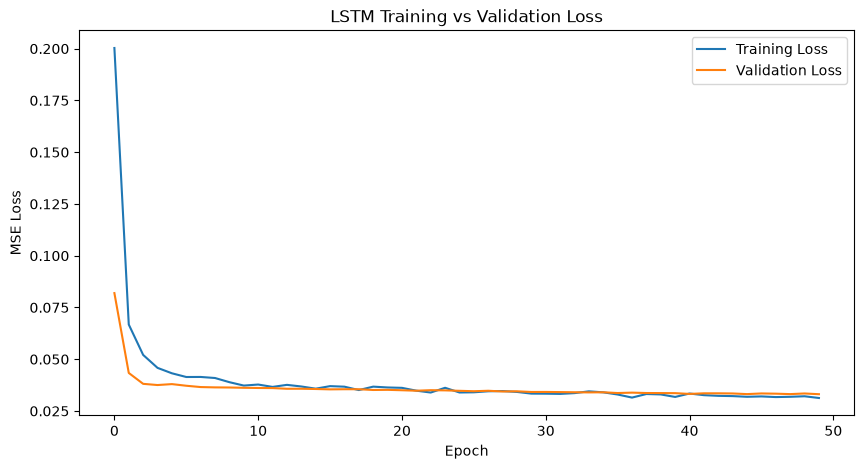

In [14]:
import matplotlib.pyplot as plt

# PLOT TRAINING / VALIDATION LOSS


plt.figure(figsize=(10, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("LSTM Training vs Validation Loss")

plt.xlabel("Epoch")

plt.ylabel("MSE Loss")

plt.legend()

plt.show()

In [15]:
# MAKE TEST PREDICTIONS

y_pred_scaled = model.predict(X_test_seq)

print("\nPrediction shape:", y_pred_scaled.shape)



2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step

Prediction shape: (60, 8)


In [16]:

# CONVERT BACK TO ORIGINAL SCALE

y_pred = scaler.inverse_transform(
    y_pred_scaled
)

y_test_original = scaler.inverse_transform(
    y_test
)


# SHOW FIRST PREDICTION
print("\nFirst Prediction:")
print(y_pred[0])

print("\nFirst Actual:")
print(y_test_original[0])



First Prediction:
[ 8.52623  17.6739   11.995316 18.350395  6.051837 10.506181 16.934834
 22.098911]

First Actual:
[ 8.16 20.   11.78 14.    7.21 18.   18.84 25.  ]


In [34]:

# FINAL MODEL EVALUATION

mae = mean_absolute_error(
    y_test_original,
    y_pred,
    multioutput="uniform_average"
)

rmse = np.sqrt(
    mean_squared_error(
        y_test_original,
        y_pred
    )
)

r2 = r2_score(
    y_test_original,
    y_pred,
    multioutput="uniform_average"
)

print("==============================")
print("FINAL LSTM RESULTS")
print("==============================")

print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R² Score: {r2:.4f}")

FINAL LSTM RESULTS
MAE: 4.0340
RMSE: 5.7550
R² Score: -0.0094


In [35]:
feature_names = [
    "Lane 1 Density",
    "Lane 1 Volume",
    "Lane 2 Density",
    "Lane 2 Volume",
    "Lane 3 Density",
    "Lane 3 Volume",
    "Lane 4 Density",
    "Lane 4 Volume"
]


print("PER-FEATURE RESULTS")

for i, name in enumerate(feature_names):

    mae_i = mean_absolute_error(
        y_test_original[:, i],
        y_pred[:, i]
    )

    rmse_i = np.sqrt(
        mean_squared_error(
            y_test_original[:, i],
            y_pred[:, i]
        )
    )

    r2_i = r2_score(
        y_test_original[:, i],
        y_pred[:, i]
    )

    print(
        f"{name}: "
        f"MAE={mae_i:.3f}, "
        f"RMSE={rmse_i:.3f}, "
        f"R²={r2_i:.3f}"
    )


PER-FEATURE RESULTS
Lane 1 Density: MAE=1.902, RMSE=2.451, R²=0.098
Lane 1 Volume: MAE=6.399, RMSE=8.073, R²=-0.096
Lane 2 Density: MAE=1.334, RMSE=1.757, R²=0.196
Lane 2 Volume: MAE=5.418, RMSE=6.945, R²=0.000
Lane 3 Density: MAE=1.125, RMSE=1.431, R²=-0.093
Lane 3 Volume: MAE=4.610, RMSE=5.820, R²=-0.173
Lane 4 Density: MAE=3.759, RMSE=4.684, R²=0.114
Lane 4 Volume: MAE=7.724, RMSE=9.198, R²=-0.120


In [36]:

# NAIVE BASELINE

# The naive model predicts that the next value
# will be the same as the most recent value.

naive_pred_scaled = X_test_seq[:, -1, :]

naive_pred = scaler.inverse_transform(
    naive_pred_scaled
)

naive_mae = mean_absolute_error(
    y_test_original,
    naive_pred
)

naive_rmse = np.sqrt(
    mean_squared_error(
        y_test_original,
        naive_pred
    )
)

naive_r2 = r2_score(
    y_test_original,
    naive_pred
)

print("\n==============================")
print("NAIVE BASELINE RESULTS")
print("==============================")

print(f"MAE: {naive_mae:.4f}")
print(f"RMSE: {naive_rmse:.4f}")
print(f"R² Score: {naive_r2:.4f}")


NAIVE BASELINE RESULTS
MAE: 4.8616
RMSE: 7.1081
R² Score: -0.2851


In [37]:
import joblib

# Save trained LSTM
model.save("traffic_lstm.keras")

# Save scaler
joblib.dump(scaler, "traffic_scaler.pkl")

print("LSTM model saved successfully.")
print("Scaler saved successfully.")

LSTM model saved successfully.
Scaler saved successfully.


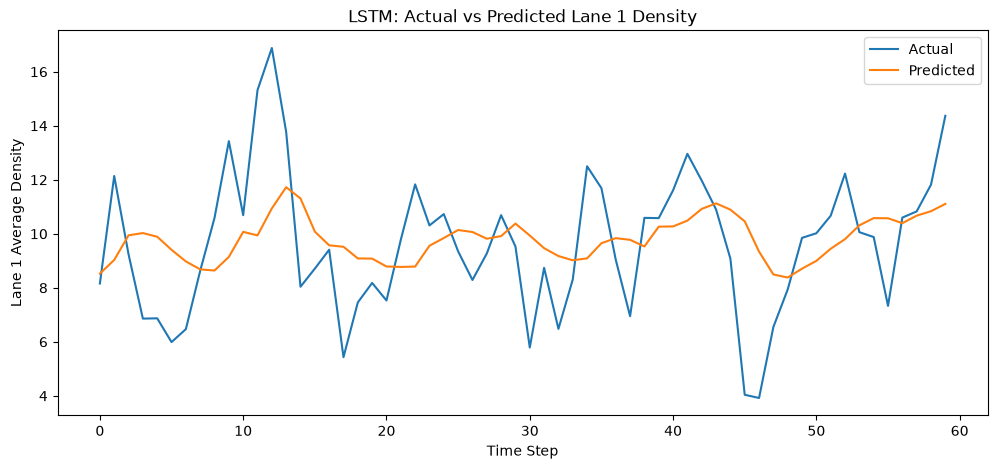

In [18]:

# ACTUAL VS PREDICTED

plt.figure(figsize=(12, 5))

plt.plot(
    y_test_original[:, 0],
    label="Actual"
)

plt.plot(
    y_pred[:, 0],
    label="Predicted"
)

plt.title(
    "LSTM: Actual vs Predicted Lane 1 Density"
)

plt.xlabel("Time Step")

plt.ylabel("Lane 1 Average Density")

plt.legend()

plt.show()

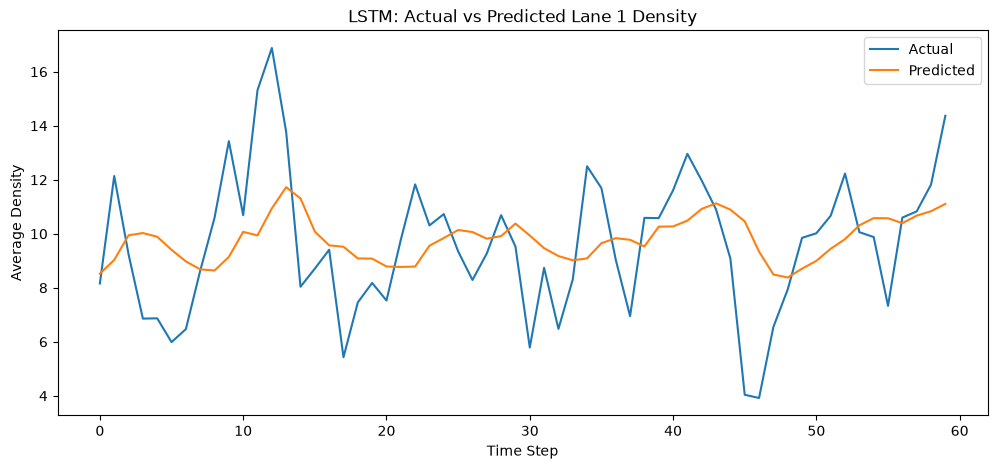

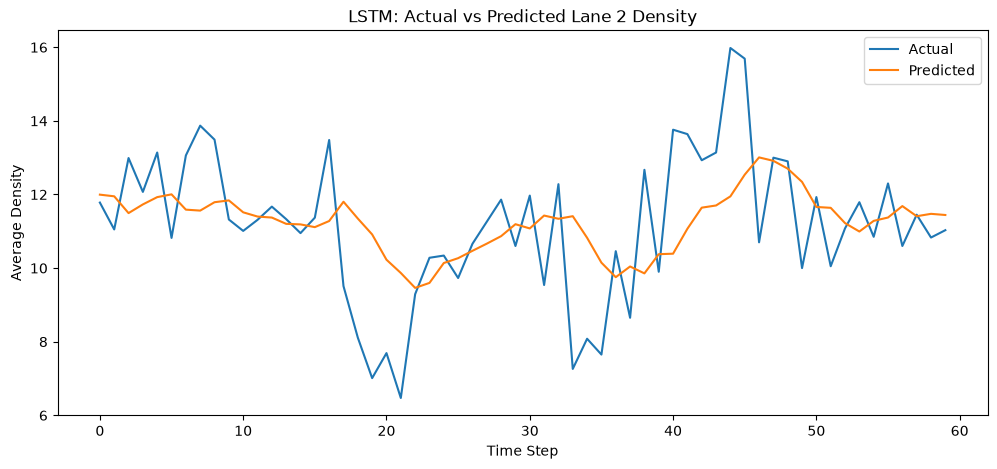

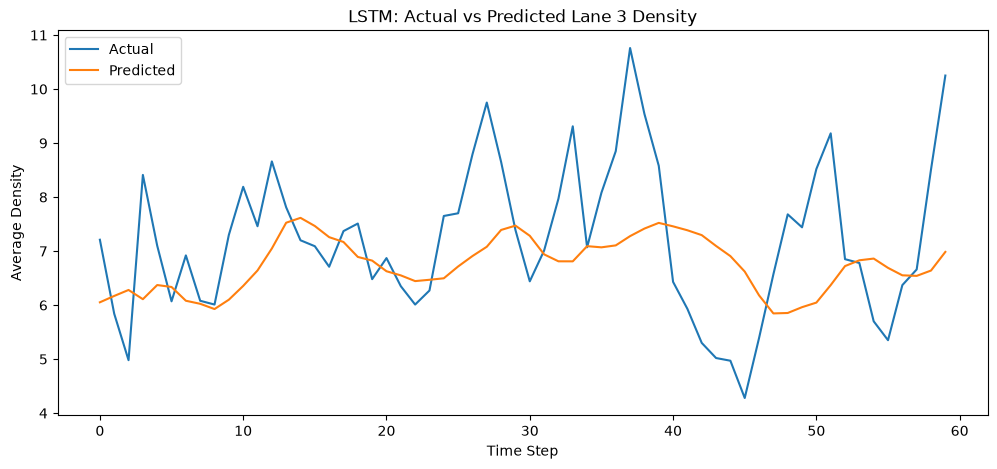

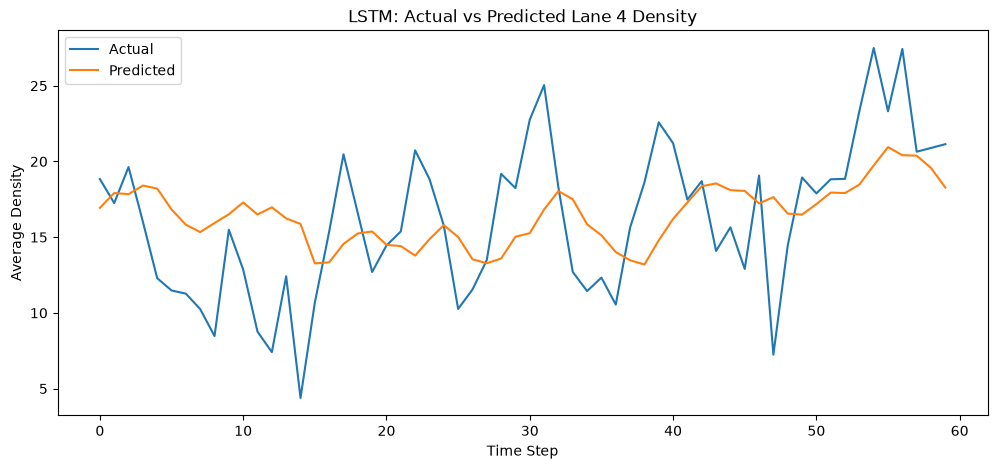

In [38]:
lane_density_indices = [0, 2, 4, 6]

lane_names = [
    "Lane 1 Density",
    "Lane 2 Density",
    "Lane 3 Density",
    "Lane 4 Density"
]

for i, lane_name in zip(lane_density_indices, lane_names):

    plt.figure(figsize=(12, 5))

    plt.plot(
        y_test_original[:, i],
        label="Actual"
    )

    plt.plot(
        y_pred[:, i],
        label="Predicted"
    )

    plt.title(
        f"LSTM: Actual vs Predicted {lane_name}"
    )

    plt.xlabel("Time Step")

    plt.ylabel("Average Density")

    plt.legend()

    plt.show()